# Machine Learning for Public Infrastructure Reliability: Predicting Water Well Status in Tanzania
Tanzania faces significant challenges in providing reliable clean water access to its population. Although many water wells have been installed, some are non-functional or require repair.

The objective of this project is to build a machine learning model capable of predicting the operational status of water wells based on pump characteristics, installation details, and geographic information.

The model can assist NGOs and government agencies in identifying wells that require maintenance and improving future well installation strategies.

## Target Variable
status_group

## Possible Classes:
- functional
- functional needs repair
- non-functional

This makes the problem a multiclass classification task.

In [2]:
#import python libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

This libraries are used for data manipulation, visualization, preprocessing and machine learning modelling.

In [3]:
#load the dataset
values = pd.read_csv("Data/Raw/Training_Set_Values.csv")
labels = pd.read_csv("Data/Raw/Training_Set_Labels.csv")

values.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [4]:
labels.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


# Loading the Datasets
The dataset is separated into two files:
- Feature data(pump characteristics)
- Target Labels (pump status)

In [5]:
#merge the values and labels dataframes on the 'id' column
df =values.merge(labels, on='id')
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [6]:
#check shape of the dataframe
df.shape

(59400, 41)

In [7]:
#inspect the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55765 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59400 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [8]:
#inspect the dataset
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


### Numerical Feature Summary

The dataset contains several numerical variables describing characteristics of water wells, including pump funding amount (`amount_tsh`), geographic elevation (`gps_height`), population served, and construction year.

Several key observations emerge:

* The **median funding amount (`amount_tsh`) is 0**, indicating that most wells have no recorded funding value or that the funding amount was not captured in the dataset.
* The **population served varies widely**, ranging from 0 to over 30,000 people, suggesting that some wells support entire communities while others serve very small populations.
* The **construction year has many zero values**, which likely represent missing or unknown installation dates rather than wells built in year zero.
* The geographic coordinates (`longitude` and `latitude`) confirm that the wells are distributed across different regions of Tanzania.

These insights suggest that the dataset contains **missing or inconsistent information** that must be handled during data preprocessing before building predictive models.


In [9]:
#Investigate the target variable
df['status_group'].value_counts()

functional                 32259
non functional             22824
functional needs repair     4317
Name: status_group, dtype: int64

In [10]:
#Investigate the target variable
df["status_group"].value_counts(normalize=True)

functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: status_group, dtype: float64

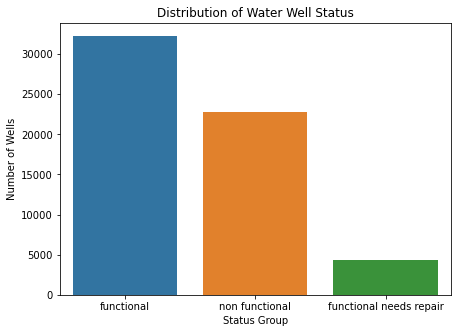

In [11]:
# plot the distribution of the target variable
plt.figure(figsize=(7,5))
sns.countplot(x='status_group', data=df)
plt.title('Distribution of Water Well Status')
plt.xlabel('Status Group')
plt.ylabel('Number of Wells')    
plt.savefig('Presentation/status_group_distribution.png')
plt.show() 


### Distribution of Water Well Status

The target variable `status_group` represents the operational condition of each water well.

The dataset contains three categories:

* **Functional** – wells that are fully operational
* **Non Functional** – wells that are broken and unable to provide water
* **Functional Needs Repair** – wells that are operational but require maintenance

The distribution shows that approximately **54% of wells are functional**, while **38% are completely non-functional**. A smaller proportion (about **7%**) require repair.

This indicates that nearly **half of the water infrastructure represented in this dataset is either broken or in need of maintenance**.

For stakeholders such as NGOs or government agencies, this highlights the importance of predictive models that can help **identify wells at risk of failure and prioritize repair efforts**.


In [12]:
#Missing Data Investigation
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

scheme_name          28166
scheme_management     3877
installer             3655
funder                3635
public_meeting        3334
permit                3056
subvillage             371
dtype: int64

In [13]:
#calculate the percentage of missing values for each column
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)

scheme_name              47.417508
scheme_management         6.526936
installer                 6.153199
funder                    6.119529
public_meeting            5.612795
permit                    5.144781
subvillage                0.624579
payment                   0.000000
waterpoint_type_group     0.000000
extraction_type_group     0.000000
extraction_type_class     0.000000
waterpoint_type           0.000000
management                0.000000
management_group          0.000000
source_class              0.000000
source_type               0.000000
water_quality             0.000000
quality_group             0.000000
extraction_type           0.000000
quantity                  0.000000
quantity_group            0.000000
source                    0.000000
payment_type              0.000000
id                        0.000000
construction_year         0.000000
basin                     0.000000
date_recorded             0.000000
gps_height                0.000000
longitude           

### Missing Data Analysis

An examination of missing values reveals that several variables contain incomplete data.

The feature **`scheme_name` has a particularly high proportion of missing values**, with nearly half of the observations lacking this information. Due to the large amount of missing data, this feature may not provide reliable information for predictive modeling.

Other variables such as **`installer`, `funder`, `public_meeting`, and `permit` contain smaller amounts of missing data**, which can be handled through appropriate imputation techniques.

Handling missing values carefully is an essential step in building reliable machine learning models, as many algorithms cannot operate directly on incomplete data.


In [14]:
#drop scheme_name column due to high percentage of missing values
df = df.drop(columns=['scheme_name'])

### Removing Features with Excessive Missing Values

The variable `scheme_name` was removed from the dataset because nearly half of its values are missing.

Features with very high missing rates often contribute little predictive information and may introduce noise into the modeling process. Removing such features simplifies the dataset and helps improve model stability.


In [15]:
#Investigate the construction year feature
(df['construction_year'] == 0).sum()

20709

In [16]:
df["construction_year"].value_counts().head(10)

0       20709
2010     2645
2008     2613
2009     2533
2000     2091
2007     1587
2006     1471
2003     1286
2011     1256
2004     1123
Name: construction_year, dtype: int64

### Construction Year Data Quality Issue

The `construction_year` variable contains a large number of entries with the value **0**, which appears more than 20,000 times in the dataset.

Since wells cannot realistically be constructed in year zero, these entries likely represent **missing or unknown installation years**.

To address this issue, the value **0 will be treated as missing data** and replaced with a more meaningful representation during feature engineering.

Rather than using the raw construction year directly, a new feature representing the **age of the water pump** will be created. Pump age is expected to be a stronger predictor of failure because older infrastructure is generally more prone to breakdown.


In [17]:
#Replace 0 values in construction_year with NaN
df['construction_year'] = df['construction_year'].replace(0, np.nan)

In [18]:
#Convert date column to datetime format
df['date_recorded'] = pd.to_datetime(df['date_recorded'], errors='coerce')

In [19]:
#extract year from date_recorded column
df['record_year'] = df['date_recorded'].dt.year

In [20]:
#confirm record_year was created successfully
df['record_year'].value_counts()

2011    28674
2013    24271
2012     6424
2004       30
2002        1
Name: record_year, dtype: int64

In [21]:
# Create a new feature Pump Age
df['pump_age'] = df['record_year'] - df['construction_year']

#check the structure of pump_age feature
df['pump_age'].describe()

count    38691.000000
mean        15.355742
std         12.492673
min         -7.000000
25%          5.000000
50%         13.000000
75%         25.000000
max         53.000000
Name: pump_age, dtype: float64

### Pump Age Distribution

The newly engineered feature **Pump Age** represents the number of years between the well's construction and the date when its condition was recorded.

The summary statistics show that the average pump age is approximately **15 years**, with most wells ranging between **5 and 25 years old**.

However, some observations contain **negative pump ages**, which indicates that the recorded construction year occurs after the inspection date. Since this is not physically possible, these values likely represent data entry errors and will be treated as missing values during preprocessing.

Cleaning these inconsistencies ensures that the dataset accurately reflects real-world infrastructure conditions.


In [22]:
#Fix Negative Pump Age Values
df.loc[df['pump_age'] < 0, 'pump_age'] = np.nan

#check the structure of pump_age feature after fixing negative values
df['pump_age'].describe()

count    38682.000000
mean        15.360245
std         12.490610
min          0.000000
25%          5.000000
50%         13.000000
75%         25.000000
max         53.000000
Name: pump_age, dtype: float64

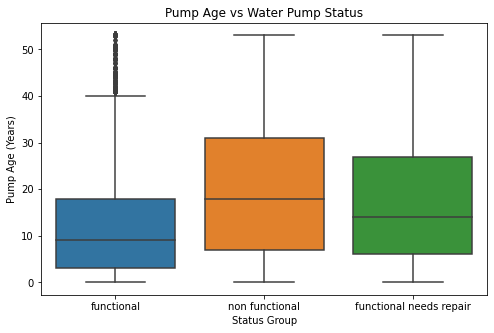

In [23]:
#Visualise Pump Age Vs Well Status
plt.figure(figsize=(8,5))
sns.boxplot(
    x='status_group',
    y='pump_age',
    data=df
)
plt.title('Pump Age vs Water Pump Status')
plt.xlabel('Status Group')  
plt.ylabel('Pump Age (Years)')
plt.savefig('Presentation/pump_age_vs_status_group.png')
plt.show()

### Relationship Between Pump Age and Well Condition

The boxplot above compares the age of water pumps across different operational conditions.

A clear pattern emerges:

* **Functional wells tend to be younger**
* **Non-functional wells generally have higher pump ages**
* Wells classified as **functional but needing repair tend to fall between the two groups**

This pattern suggests that **infrastructure aging plays a significant role in well failure**. As pumps grow older, the likelihood of malfunction or breakdown increases.

This insight is valuable for policymakers and NGOs because it indicates that **preventative maintenance strategies could focus on older wells to reduce the risk of complete failure**.


In [24]:
#Explore Installer Patterns
df['installer'].value_counts().head(15)

DWE                   17402
Government             1825
RWE                    1206
Commu                  1060
DANIDA                 1050
KKKT                    898
Hesawa                  840
0                       777
TCRS                    707
Central government      622
CES                     610
Community               553
DANID                   552
District Council        551
HESAWA                  539
Name: installer, dtype: int64

### Installer Patterns
Most wells were installed by DWE, followed by smaller contributions from government and community based organisations in Tanzania. There is also some inconsistent data e.g 0 or variations like DANIDA vs DANID and Hesawa vs HESAWA that should be cleaned.

In [25]:
#Clean Installer Names
# Standardize installer names
df['installer'] = df['installer'].str.upper().str.strip()

# Merge obvious duplicates
df['installer'] = df['installer'].replace({
    'DANID': 'DANIDA',
    'HESAWA': 'HESAWA',  # already upper, but good habit
    'COMMU': 'COMMUNITY',
    '0': np.nan  # treat missing installer as NaN
})

## Installer Cleaning
I have standardized the installer names to uppercase and removed whitespace, then merged duplicates. This ensure our analysis is consistent and avoids splitting the same installer into multiple categories.

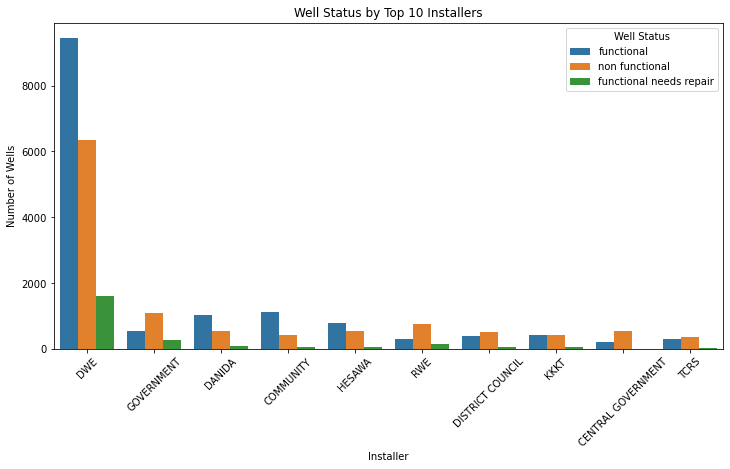

In [26]:
# Visualise top 10 Installer vs Operational Status
top_installers = df['installer'].value_counts().nlargest(10).index

plt.figure(figsize=(12,6))
sns.countplot(
    data=df[df['installer'].isin(top_installers)],
    x='installer',
    hue='status_group',
    order=top_installers
)
plt.xticks(rotation=45)
plt.title('Well Status by Top 10 Installers')
plt.ylabel('Number of Wells')
plt.xlabel('Installer')
plt.legend(title='Well Status')
plt.savefig('Presentation/well_status_by_top_installers.png', bbox_inches='tight')
plt.show()

### Well Status By Top 10 Installers Insights
Our analysis shows that the choice of installer has a meaningful impact on the operational status of water wells. 

DWE-installed wells perform best, while wells from smaller or less established installers are more likely to fail or require repairs. This information can help prioritize maintenance and improve future well installation programs

In [27]:
#keep top 10 most frequent installers and replace the rest with 'Other'
top_installers = df['installer'].value_counts().nlargest(10).index

#group less frequent installers into 'Other'
df['installer_grouped'] = df['installer'].apply(
    lambda x: x if x in top_installers else 'Other')

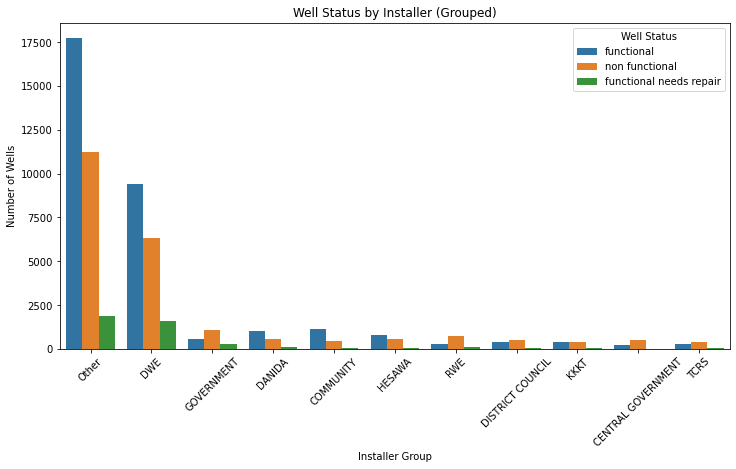

In [28]:
#Revisualise top 10 Installer vs Operational Status with grouped installers
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='installer_grouped',
    hue='status_group',
    order=df['installer_grouped'].value_counts().index
)
plt.xticks(rotation=45)
plt.title('Well Status by Installer (Grouped)')
plt.ylabel('Number of Wells')   
plt.xlabel('Installer Group')
plt.legend(title='Well Status')
plt.savefig('Presentation/well_status_by_installer_grouped.png', bbox_inches='tight')   
plt.show()

In [29]:
#using a normalized cross-tabulation to show the proportion of each status group within each installer group
installer_status_pct = pd.crosstab(
    df['installer_grouped'],
    df['status_group'],
    normalize='index'
) * 100

installer_status_pct.round(2)

status_group,functional,functional needs repair,non functional
installer_grouped,,,
CENTRAL GOVERNMENT,28.57,1.05,70.38
COMMUNITY,68.70,4.51,26.79
DANIDA,61.95,5.68,32.38
DISTRICT COUNCIL,40.06,6.35,53.59
DWE,54.20,9.32,36.48
GOVERNMENT,29.19,13.64,57.17
HESAWA,56.34,3.87,39.78
KKKT,46.70,6.81,46.48
Other,57.39,6.17,36.44


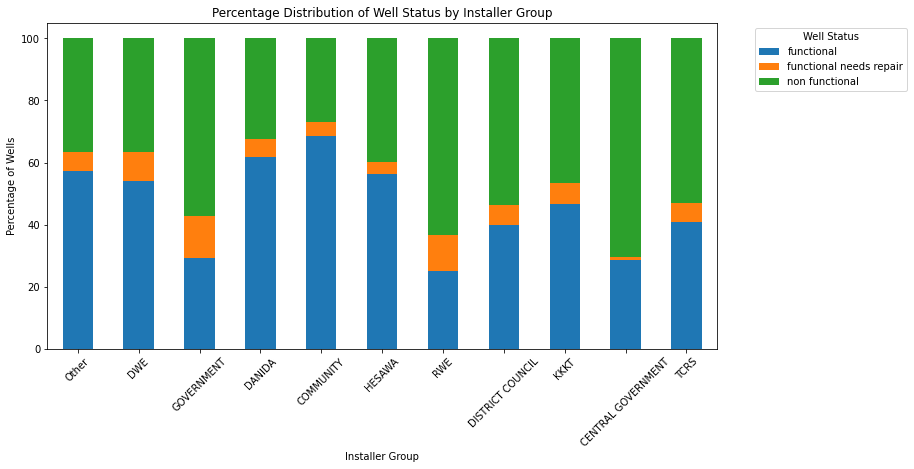

In [30]:
#plot a stacked bar chart to visualize the proportion of each status group within each installer group
installer_status_pct = pd.crosstab(
    df['installer_grouped'],
    df['status_group'],
    normalize='index'

) * 100
installer_status_pct = installer_status_pct.loc[
    df['installer_grouped'].value_counts().index
]

installer_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Percentage Distribution of Well Status by Installer Group')
plt.xlabel('Installer Group')
plt.ylabel('Percentage of Wells')
plt.xticks(rotation=45)
plt.legend(title='Well Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('Presentation/percentage_distribution_well_status_by_installer_group.png', bbox_inches='tight')
plt.show()


## Percentage Distribution of Well Status by Installer Group

This table shows the proportion of well statuses within each installer group, which provides a fairer comparison than raw counts because installer groups differ greatly in size.

Key findings:
- COMMUNITY installers show relatively strong performance, with 68.7% of wells functional and only 26.8% non-functional.
- DANIDA also performs well, with 62.0% functional wells and a comparatively lower failure rate (32.4% non-functional).
- The grouped Other category performs moderately well, with 57.4% functional wells and 36.4% non-functional wells. Since this category combines many smaller installers, it reflects an average of mixed outcomes rather than a single installer’s performance.
- DWE, the most common installer, shows 54.2% functional wells, 9.3% needing repair, and 36.5% non-functional wells. This suggests that while DWE contributes many functioning wells in total, its proportional performance is more moderate than some smaller installer groups.
- HESAWA also shows relatively balanced performance, with 56.3% functional wells.
- Some installer groups are associated with much weaker outcomes:
    - RWE has only 25.2% functional wells, while 63.4% are non-functional
    - CENTRAL GOVERNMENT has 28.6% functional wells and 70.4% non-functional
    - GOVERNMENT has 29.2% functional wells and 57.2% non-functional
    - DISTRICT COUNCIL and TCRS also show more than 50% non-functional wells

## Business Implication
The installer appears to be a meaningful predictor of well performance. Some installer groups are associated with a much higher share of functioning wells, while others show a much greater likelihood of failure. This suggests that installation practices, quality control, or maintenance environments may differ across installer groups.

From a practical perspective, this insight can help stakeholders:
- identify wells that may be at higher risk of failure,
- prioritize monitoring or maintenance for wells installed by underperforming groups,
- inform future procurement or contractor selection decisions.

In [31]:
#fix other to match the other category in the installer_grouped feature
df['installer_grouped'] = df['installer_grouped'].replace('Other', 'OTHER')

In [32]:
#Exploer funder patterns
df['funder'].value_counts().head(15)

Government Of Tanzania    9084
Danida                    3114
Hesawa                    2202
Rwssp                     1374
World Bank                1349
Kkkt                      1287
World Vision              1246
Unicef                    1057
Tasaf                      877
District Council           843
Dhv                        829
Private Individual         826
Dwsp                       811
0                          777
Norad                      765
Name: funder, dtype: int64

### Initial Exploration of the funder Feature

The funder variable identifies the organization that financed the water well project. This is a potentially important feature because funding sources may influence:
- the quality of installation,
- the choice of equipment,
- access to maintenance resources,
- the long-term sustainability of the water point.

**Key observations from the distribution:**
- **Government Of Tanzania** is the most common funder by a large margin, with 9,084 wells.
- Other major funders include:
    - Danida (3,114)
    - Hesawa (2,202)
    - Rwssp (1,374)
    - World Bank (1,349)
    - Kkkt (1,287)
    - World Vision (1,246)
    - Unicef (1,057)
- The presence of 0 indicates missing or placeholder values that should be treated as unknown or missing data.
- Similar to the installer feature, the funder column appears to contain:
    - high cardinality,
    - inconsistent capitalization,
    - likely many rare categories.

### Business implication:
Because different funders may follow different standards, project management practices, or maintenance support models, the funder feature may contain useful predictive signal for identifying whether a well remains functional.

In [33]:
# clean funder names
# Standardize funder names
df['funder'] = df['funder'].astype(str).str.upper().str.strip()

# Replace placeholder / missing-like values
df['funder'] = df['funder'].replace({
    '0': np.nan,
    'NONE': np.nan,
    'NAN': np.nan
})

# Merge obvious duplicates / standardize common names
df['funder'] = df['funder'].replace({
    'GOVERNMENT OF TANZANIA': 'GOVERNMENT',
    'KKKT': 'KKKT',   # already standardized after uppercase
    'HESAWA': 'HESAWA',
    'DANIDA': 'DANIDA'
})

## Cleaning and Standardizing the funder Feature

The funder feature contains a large number of categories, including inconsistent capitalization and placeholder values such as 0, which likely represent missing information.

To improve data quality:
- text values were standardized to uppercase,
- placeholder values were treated as missing,
- common naming variations were consolidated where appropriate.

This ensures that the same funding organization is not split across multiple labels and improves the reliability of downstream analysis and modeling.

In [34]:
# Create funder groups based on frequency
# Keep top 10 most frequent funders
top_funders = df['funder'].value_counts().nlargest(10).index

# Group less frequent funders into OTHER
df['funder_grouped'] = df['funder'].apply(
    lambda x: x if x in top_funders else 'OTHER'
)

## Grouping Rare Funder Categories

The funder feature has high cardinality, meaning it contains many unique categories, most of which occur infrequently.

To reduce noise and make the feature more suitable for machine learning:
- the top 10 most frequent funders were retained as separate categories,
- while all less frequent funders were grouped into a single OTHER category.

This preserves the signal from major funding organizations while preventing the model from being overwhelmed by many sparse categories.

In [35]:
# check grouped counts
df['funder_grouped'].value_counts()

OTHER               36965
GOVERNMENT           9086
DANIDA               3114
HESAWA               2202
RWSSP                1374
WORLD BANK           1349
KKKT                 1287
WORLD VISION         1246
UNICEF               1057
TASAF                 877
DISTRICT COUNCIL      843
Name: funder_grouped, dtype: int64

## Business implication:

This confirms that funding is concentrated among a few major organizations, while a large number of smaller funders each contribute relatively few wells. Because of this imbalance, raw counts are useful for understanding which funders are most common, but not for evaluating which funders are associated with better or worse well performance.

To assess funder-related performance fairly, we need to examine the percentage distribution of well status within each funder group rather than absolute counts.

## Why Percentage-Based Comparison Is Needed for funder

Because the grouped funder categories vary greatly in size, comparing raw counts alone can be misleading.

For example, the OTHER category combines many smaller funders, so it naturally contains a large number of wells. As a result, it may appear to contribute the highest number of functional wells simply because it represents a larger total volume.

To evaluate funder performance more fairly, it is more appropriate to compare the percentage distribution of well status within each funder group rather than absolute counts. This allows us to assess the relative reliability associated with each funder regardless of how many wells they funded.

In [36]:
funder_status_pct = pd.crosstab(
    df['funder_grouped'],
    df['status_group'],
    normalize='index'
) * 100

funder_status_pct.round(2)

status_group,functional,functional needs repair,non functional
funder_grouped,,,
DANIDA,55.01,5.11,39.88
DISTRICT COUNCIL,44.84,5.34,49.82
GOVERNMENT,40.96,7.72,51.32
HESAWA,42.51,10.54,46.96
KKKT,56.18,5.13,38.69
OTHER,58.44,7.07,34.49
RWSSP,58.59,7.93,33.48
TASAF,56.21,7.30,36.49
UNICEF,56.76,9.37,33.87


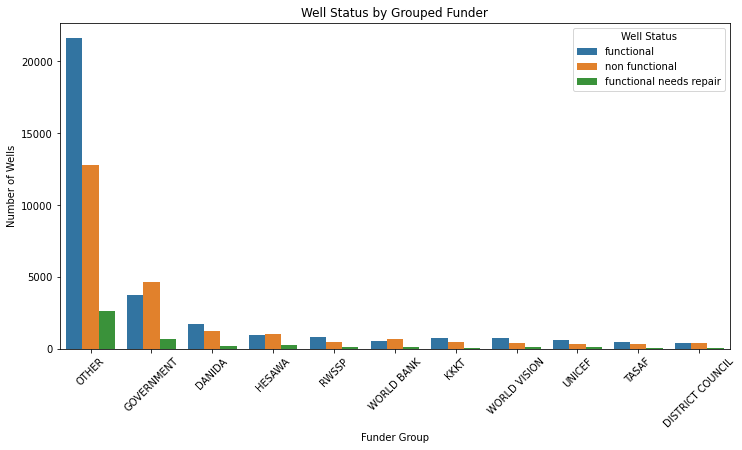

In [37]:
# Visualising funder grouped vs well status
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='funder_grouped',
    hue='status_group',
    order=df['funder_grouped'].value_counts().index
)
plt.title('Well Status by Grouped Funder')
plt.xlabel('Funder Group')
plt.ylabel('Number of Wells')
plt.xticks(rotation=45)
plt.legend(title='Well Status')
plt.savefig('Presentation/well_status_by_grouped_funder.png', bbox_inches='tight')
plt.show()

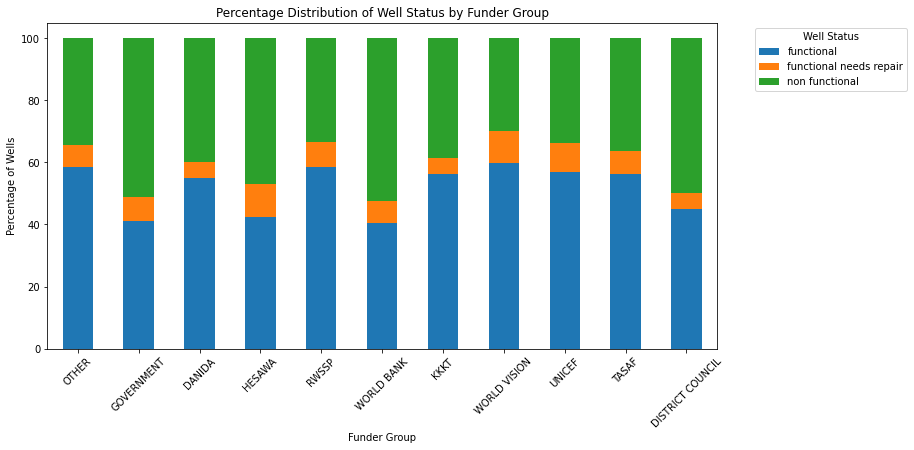

In [38]:
# stacked percentage bar chart for funder grouped vs well status
funder_status_pct = pd.crosstab(
    df['funder_grouped'],
    df['status_group'],
    normalize='index'
) * 100

funder_status_pct = funder_status_pct.loc[
    df['funder_grouped'].value_counts().index
]

funder_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Percentage Distribution of Well Status by Funder Group')
plt.xlabel('Funder Group')
plt.ylabel('Percentage of Wells')
plt.xticks(rotation=45)
plt.legend(title='Well Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('Presentation/percentage_distribution_well_status_by_funder_group.png', bbox_inches='tight')
plt.show()

## Percentage Distribution of Well Status by Funder Group

This table shows the proportion of well statuses within each funder group, which allows for a fair comparison regardless of how many wells each funder supports.

Key findings:
- WORLD VISION shows one of the strongest outcomes, with 59.6% of wells functional and only 29.9% non-functional.
- RWSSP also performs well, with 58.6% functional wells and 33.5% non-functional.
- The grouped OTHER category performs relatively well overall, with 58.4% functional wells and 34.5% non-functional wells. Since this category combines many smaller funders, it reflects a blended average rather than a single organization’s performance.
- UNICEF, TASAF, KKKT, and DANIDA also show relatively favorable outcomes, each with more than 55% functional wells.
- Some funders are associated with weaker outcomes:
    - WORLD BANK has 52.4% non-functional wells
    - GOVERNMENT has 51.3% non-functional wells
    - DISTRICT COUNCIL has 49.8% non-functional wells
    - HESAWA also shows a relatively high non-functional rate (47.0%)

## Business implication:

The funding source appears to be a meaningful predictor of well performance. Some funders are associated with a higher proportion of functioning wells, while others are associated with a higher proportion of failed wells.

This suggests that differences in:
- project implementation standards,
- contractor selection,
- maintenance planning,
- long-term support models

may influence operational outcomes.

From a stakeholder perspective, this insight can support:
- risk-based monitoring of water points,
- more targeted maintenance planning,
- better-informed decisions about future funding partnerships

In [39]:
# Explore the extraction_type_class feature
df['extraction_type_class'].value_counts()

gravity         26780
handpump        16456
other            6430
submersible      6179
motorpump        2987
rope pump         451
wind-powered      117
Name: extraction_type_class, dtype: int64

## Distribution of Extraction Type Class

The extraction_type_class feature describes the broad type of mechanism used to extract water from the well. This is a highly relevant operational feature because the extraction technology may affect:
- reliability,
- maintenance requirements,
- energy dependence,
- long-term performance.

Key observations:
- Gravity systems are the most common, with 26,780 wells, making them the dominant extraction mechanism in the dataset.
- Handpump systems are also widely used, with 16,456 wells.
- Other common categories include:
    - Other (6,430)
    - Submersible (6,179)
    - Motorpump (2,987)
- Less common extraction types include:
    - Rope pump (451)
    - Wind-powered (117)

## Business implication:

This distribution suggests that the dataset is dominated by a few extraction technologies, especially gravity and handpump systems. Because different technologies may have different durability and maintenance needs, this feature is likely to be an important predictor of whether a water point remains functional.

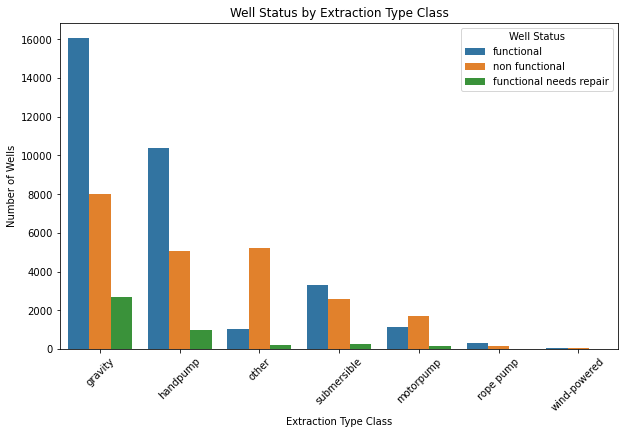

In [40]:
# Visualize the extraction_type_class feature vs well status
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='extraction_type_class',
    hue='status_group',
    order=df['extraction_type_class'].value_counts().index
)
plt.title('Well Status by Extraction Type Class')
plt.xlabel('Extraction Type Class')
plt.ylabel('Number of Wells')
plt.xticks(rotation=45)
plt.legend(title='Well Status')
plt.savefig('Presentation/well_status_by_extraction_type_class.png', bbox_inches='tight')
plt.show()

In [41]:
# Drop redundant columns that won't be used in modeling
drop_cols = [
"id",
"wpt_name",
"recorded_by",
"scheme_name",
"date_recorded",
"num_private"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [42]:
# drop duplicate features and remain with one version of each feature
df = df.drop(columns=[
"extraction_type_group",
"extraction_type_class"
])

In [43]:
# drop other unused columns in modelling
df = df.drop(columns=[
"payment",
"quality_group",
"quantity_group",
"source_type",
"source_class",
"waterpoint_type_group"
])

In [44]:
# Separate features and target variable
X = df.drop(columns=['status_group'], axis=1)
y = df['status_group']

In [45]:
#Identify Numerical and Categorical Columns
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [46]:
#print numeric and categorical features
print(len(numeric_features))
print(len(categorical_features))

10
20


In [47]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
# Build preprocessing pipelines for numeric features
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [49]:
# Building a preprocessing pipeline for categorical features
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [50]:
#combine numeric and categorical pipelines into a preprocessor
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [51]:
# Baseline Model with Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
("preprocessing", preprocessor),
("model", model)
])

### Baseline Model: Random Forest Classifier

We begin with a **Random Forest model**, a powerful ensemble learning algorithm that builds multiple decision trees and aggregates their predictions.

Random forests perform well on tabular datasets with mixed feature types and are robust to nonlinear relationships and interactions between variables.

The model is trained using the preprocessing pipeline created earlier, ensuring that both numerical and categorical variables are properly transformed before training.


In [52]:
#Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['amount_tsh', 'gps_height', 'longitude', 'latitude', 'region_code',
       'district_code', 'population', 'construction_year', 'record_year',
       'pump_age'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('...
                                                  Index(['funder', 'installer', 'basin', 'subvillage', 'region', 'lga', 'ward',
       'public_meeting', 'scheme_management', 'permit', 'extract

### Model Evaluation

After training the model, we evaluate its performance on the test dataset.
The goal is to assess how well the model generalizes to unseen data.

We examine:

* **Accuracy** – overall prediction correctness
* **Precision and Recall** – class-level performance
* **Confusion Matrix** – distribution of prediction errors


In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:",cm)
print(classification_report(y_test, y_pred))

Accuracy: 0.8048821548821549


NameError: name 'cm' is not defined

### Model Performance Interpretation

The Random Forest model achieved an accuracy of approximately **80%**, indicating strong overall predictive performance.

However, a closer look at the class-level metrics reveals important differences:

* The model performs well in predicting **functional wells**, with high recall and precision.
* It also performs strongly on **non-functional wells**, which is critical for identifying failed infrastructure.
* Performance is weaker for the **"functional needs repair"** category, with lower recall and F1-score.

This suggests that the model has difficulty distinguishing wells that are partially functional from those that are fully functional or completely non-functional.


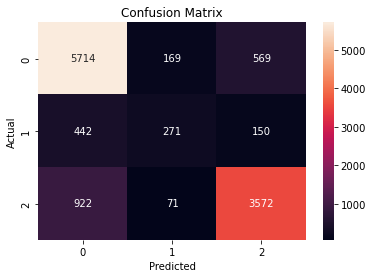

In [ ]:
#Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)   
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Presentation/confusion_matrix.png', bbox_inches='tight')
plt.show()

### Feature Importance Analysis

Tree-based models such as Random Forest allow us to measure the **relative importance of features** used in making predictions.

Understanding which variables contribute most to the model helps identify the **key drivers of well functionality**, which can provide useful insights for policy makers and NGOs involved in infrastructure planning.


In [ ]:
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(15)

,feature,importance
2,num__longitude,0.067262
3,num__latitude,0.066352
1,num__gps_height,0.038379
22994,cat__quantity_dry,0.036715
6,num__population,0.027383
7,num__construction_year,0.023888
9,num__pump_age,0.022964
22995,cat__quantity_enough,0.021682
23015,cat__waterpoint_type_other,0.018012
22953,cat__extraction_type_other,0.016156


### Key Drivers of Well Functionality

Feature importance analysis reveals the most influential variables in predicting well status.

The most important features include:

* **Geographic location (longitude and latitude)** – These are the strongest predictors, suggesting that well performance is highly dependent on location-specific factors such as environment, infrastructure, and regional management.
* **GPS height** – Elevation appears to influence water availability and infrastructure durability.
* **Water quantity (e.g., dry, enough)** – Wells with insufficient or dry water supply are strongly associated with failure.
* **Population served** – Wells serving larger populations may experience more strain and higher failure rates.
* **Construction year and pump age** – Older wells are more likely to be non-functional or require repair.

These findings indicate that both **environmental factors** and **infrastructure characteristics** play a key role in determining well performance.


### Importance of Geographic Features

The dominance of geographic features such as latitude and longitude suggests that **location-based patterns** are critical in understanding well functionality.

This may reflect:

* Regional differences in maintenance practices
* Environmental conditions such as rainfall and groundwater levels
* Variations in infrastructure investment across regions

This insight highlights the importance of incorporating **spatial analysis** in future work.


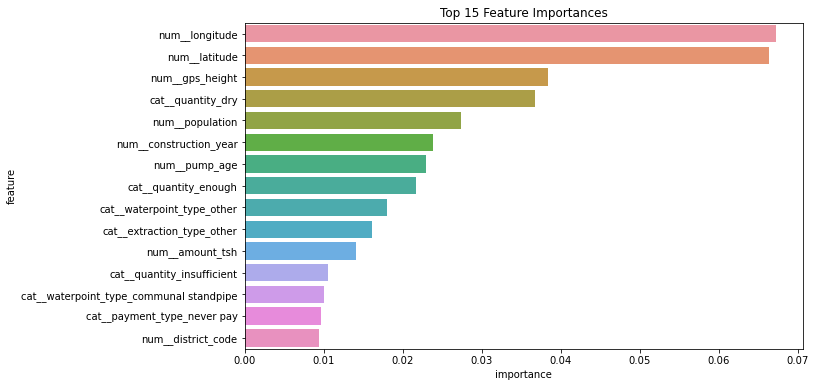

In [ ]:
#visualize top features
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="importance", y="feature")

plt.title("Top 15 Feature Importances")
plt.savefig("Presentation/Top_15_Feature_Importances")

plt.show()

### Model Comparison: Gradient Boosting

To compare model performance, we train a **Gradient Boosting classifier**.
Gradient Boosting builds trees sequentially, where each new tree attempts to correct errors made by previous trees.

This method often achieves strong predictive performance on structured datasets.


In [ ]:
# Second Model - Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.7598484848484849


### Model Comparison: Extra Trees Classifier

The Extra Trees classifier is another ensemble tree-based algorithm similar to Random Forest.
However, it introduces additional randomness when splitting nodes, which can sometimes improve generalization and reduce variance.


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

et_pipeline.fit(X_train, y_train)

et_pred = et_pipeline.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, et_pred))

Extra Trees Accuracy: 0.7944444444444444


### Model Performance Comparison

Multiple models were trained to evaluate which algorithm performs best for predicting well conditions.

Comparing different models helps ensure that the final solution is not dependent on a single algorithm and allows us to select the most effective approach for this problem.


In [ ]:
model_results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "Extra Trees"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, et_pred)
    ]
})

model_results

,Model,Accuracy
0,Random Forest,0.804461
1,Gradient Boosting,0.759848
2,Extra Trees,0.794444


### Model Comparison

Three machine learning models were evaluated:

* **Random Forest** achieved the highest accuracy (~80%)
* **Extra Trees** performed slightly lower (~79%)
* **Gradient Boosting** showed the lowest performance (~76%)

The superior performance of Random Forest suggests that the dataset benefits from **bagging-based ensemble methods**, which are effective at handling noisy and high-dimensional data.

Gradient Boosting, while powerful, may require more careful tuning to achieve optimal performance in this case.


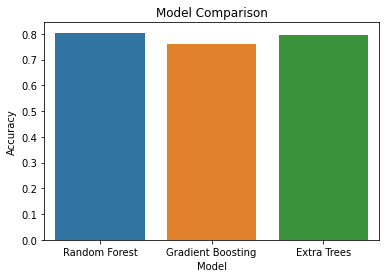

In [ ]:
#Model comparison visualisation
sns.barplot(data=model_results, x="Model", y="Accuracy")

plt.title("Model Comparison")
plt.savefig("Presentation/Model Comparison")

plt.show()

### Final Model Selection

Based on performance comparison, the **Random Forest model** was selected as the final model due to its:

* Highest predictive accuracy
* Robustness to noise and overfitting
* Ability to handle both numerical and categorical features effectively

This model provides a strong balance between performance and interpretability for the problem at hand.


### Insights for Decision Makers

The analysis provides several actionable insights:

* Wells in certain geographic regions are significantly more likely to fail, indicating a need for **region-specific interventions**.
* Older wells and those with declining water quantity should be prioritized for **maintenance and replacement**.
* Wells serving larger populations may require more frequent monitoring to prevent breakdowns.
* Certain extraction and waterpoint types are associated with higher failure rates, suggesting opportunities for **improved infrastructure design**.

These insights can help governments and NGOs allocate resources more efficiently and improve access to clean water.


### Conclusion

This project successfully developed a machine learning model to predict the operational status of water wells in Tanzania.

The Random Forest model achieved strong predictive performance and identified key factors influencing well functionality, including geographic location, water availability, and infrastructure characteristics.

The results demonstrate how data-driven approaches can support better decision-making in public infrastructure management and contribute to improving access to clean water.


### Future Work
- Hyperparameter tuning
- Geospatial modeling
- Handling class imbalance further